In [1]:
import matplotlib.pyplot as plt
from config.initialize import *
from config.settings import *
from model.dualscale import PEMFC
from scipy.integrate import solve_ivp
from modules.display import display

In [2]:
from modules.nan_tracker import NaNTracker, quick_nan_check, solve_with_nan_tracking

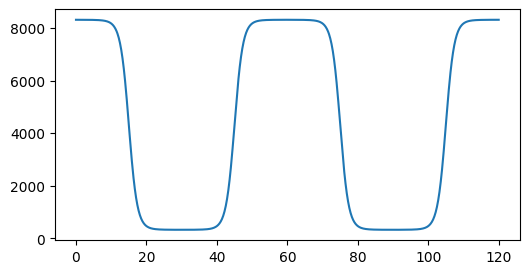

In [3]:
def AST_protocol(t):
    """
    Generates a smoothed square wave current signal using tanh transitions.
    
    Parameters:
    t (float): Time in seconds
    
    Returns:
    float: Current density value
    """
    T = 60.0  # Cycle duration in seconds
    I_low = 1  # Lower current limit in Amperes
    I_high = 25.8  # Upper current limit in Amperes
    smoothing = 4.0  # Controls sharpness of the transition: smaller -> gentler

    phase = 2.0 * np.pi * t / T
    wave = 0.5 * (1.0 + np.tanh(smoothing * np.cos(phase)))
    current = I_low + (I_high - I_low) * wave
    return current / parameters['Aact']
plt.figure(figsize=(6, 3))
plt.plot(np.linspace(0, 120, 1000), [AST_protocol(t) for t in np.linspace(0, 120, 1000)])

In [4]:
operating_inputs["current_density"] = lambda x: 0.4e4 
model = PEMFC(param=parameters, variable_names=solver_variable_names, flux_names=solver_flux_names, operating_inputs=operating_inputs)
solution_init = init_x(operating_inputs, parameters)

# Solve with integrated NaN tracking
print("=" * 80)
print("FIRST SIMULATION - Constant Current")
print("=" * 80)
solution, nan_wrapper_1 = solve_with_nan_tracking(
    model=model,
    t_span=(0, 10),
    y0=solution_init,
    method='BDF',
    max_step=1e-1
)

FIRST SIMULATION - Constant Current
Starting ODE integration with NaN tracking...
  Method: BDF
  Time span: (0, 10)
  Initial state size: 181

✓ Integration completed
  Total ODE calls: 6869
  Solution shape: (181, 177)
✓ No NaN detected during integration



## AST protocol

In [5]:
operating_inputs["current_density"] = AST_protocol
operating_inputs["Pa_des"] = 1.5e5
operating_inputs["Pc_des"] = 1.5e5
operating_inputs["Tfc"] = 343.15
operating_inputs["Phi_a_des"] = 0
operating_inputs["Phi_c_des"] = 0.5
operating_inputs["Sa"] = 1.2
operating_inputs["Sc"] = 2.5

In [6]:
model = PEMFC(param=parameters, variable_names=solver_variable_names, flux_names=solver_flux_names, operating_inputs=operating_inputs)
jac_sparsity = model.compute_jac_sparsity(solution_init)
print("Jacobian sparsity pattern computed")

d:\MFC2024\model\inst_values.py:261: RuntimeWarning: invalid value encountered in scalar power
  ans1 = (mliquid * Lgc * nu_l(Tfc)/ (Hgc * rho_H2O(Tfc) * nu_g)) ** (1/3)


Jacobian sparsity pattern computed


In [7]:
# Check jacobian sparsity pattern and initial state again
print(f"Jacobian sparsity: {jac_sparsity.shape}, {jac_sparsity.nnz} non-zeros")

# Additional check on solution_init
tracker = NaNTracker()
print("\nDetailed check on solution_init:")
nan_details = tracker._check_value('solution_init', solution_init)
if nan_details:
    print(f"Found {len(nan_details)} NaN values in solution_init")
    tracker.print_summary()
else:
    print("✓ No NaN in solution_init")

Jacobian sparsity: (181, 181), 1450 non-zeros

Detailed check on solution_init:
✓ No NaN in solution_init


In [8]:
# AST protocol simulation with integrated NaN tracking
print("=" * 80)
print("AST PROTOCOL SIMULATION")
print("=" * 80)
solution, nan_wrapper_2 = solve_with_nan_tracking(
    model=model,
    t_span=(0, 30),
    y0=solution.y[:,-1],
    method='BDF',
    max_step=1e-1
)

AST PROTOCOL SIMULATION
Starting ODE integration with NaN tracking...
  Method: BDF
  Time span: (0, 30)
  Initial state size: 181


⚠ NaN DETECTED in ODE evaluation!
  Time: 17.871177344146542
  Call #: 8073
  Variable: s_cgdl_10 (index 90)
  ds_cgdl_10/dt = nan
  s_cgdl_10(t) = -1.748646015665857e-12

✗ Integration failed: array must not contain infs or NaNs

⚠ NaN REPORT: 187 event(s) in 8266 ODE calls

Event #1:
  Time:          17.871177344146542
  ODE Call #:    8073
  Variable:      s_cgdl_10 (index 90)
  ds_cgdl_10/dt = nan
  s_cgdl_10(t) = -1.748646015665857e-12

Event #2:
  Time:          17.82117734414654
  ODE Call #:    8075
  Variable:      s_cgdl_10 (index 90)
  ds_cgdl_10/dt = nan
  s_cgdl_10(t) = -1.7484030921675434e-12

Event #3:
  Time:          17.796177344146543
  ODE Call #:    8077
  Variable:      s_cgdl_10 (index 90)
  ds_cgdl_10/dt = nan
  s_cgdl_10(t) = -1.7482816304183867e-12

Event #4:
  Time:          17.78367734414654
  ODE Call #:    8079
  Variable:    

ValueError: array must not contain infs or NaNs

In [ ]:
# Track NaN in the AST protocol simulation
print("Starting AST protocol simulation...")
print(f"Initial state shape: {solution.y[:,-1].shape}")

tracker = NaNTracker()
nan_check_1 = tracker._check_value('previous_solution', solution.y[:,-1])
if nan_check_1:
    print("⚠ NaN found in previous solution state!")
    tracker.print_summary()

try:
    solution = solve_ivp(fun=model.dxdt, t_span=(0, 30), y0=solution.y[:,-1], method='BDF', max_step = 1e-1)
    print("✓ AST protocol solve_ivp completed")
    
    # Check result for NaN
    tracker2 = NaNTracker()
    nan_vars = tracker2.check_variables({'solution_y': solution.y}, 'ast_protocol_solve')
    if nan_vars:
        print(f"\n⚠ WARNING: Found {len(nan_vars)} NaN value(s) in solution!")
        tracker2.print_summary()
        report = tracker2.get_nan_report()
        print(f"\nVariables with NaN: {report['affected_variables']}")
    else:
        print("✓ No NaN in AST protocol solution")
        
except Exception as e:
    print(f"✗ Error during AST protocol simulation: {e}")
    import traceback
    traceback.print_exc()

In [ ]:
model._recovery(solution)

## Cell performance

Text(0.5, 0, 'Time (s)')

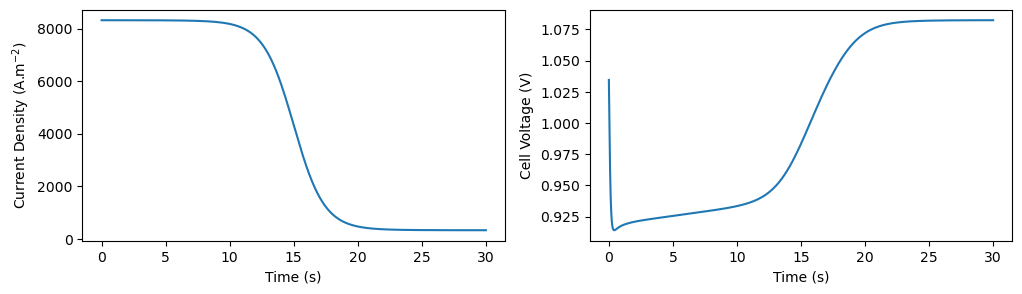

In [ ]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12,3))
ax[0].plot(model.variables['t'], model.echem_traj['i_fc'])
ax[0].set_ylabel('Current Density (A.m$^{-2}$)')
ax[0].set_xlabel('Time (s)')
ax[1].plot(model.variables['t'], model.echem_traj['Ucell'], label='Current Density (A)')
ax[1].set_ylabel('Cell Voltage (V)')
ax[1].set_xlabel('Time (s)')

(142500.0, 157500.0)

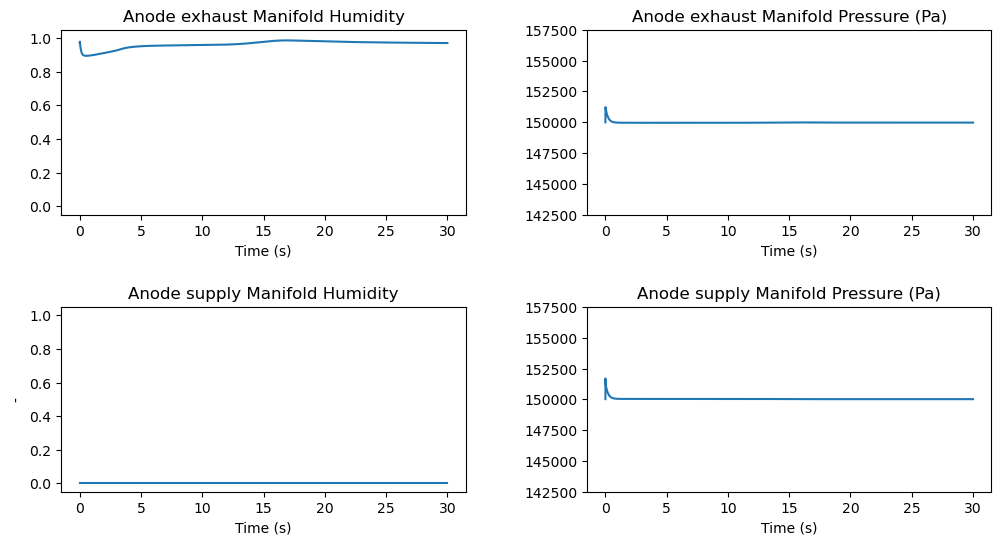

In [ ]:
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(12,6))
plt.subplots_adjust(hspace=0.5, wspace=0.3)
ax[0,0].plot(model.variables['t'], model.variables['Phi_aem'])
ax[0,0].set_xlabel('Time (s)')
ax[0,0].set_title('Anode exhaust Manifold Humidity')
ax[0,1].plot(model.variables['t'], model.variables['Paem'])
ax[0,1].set_xlabel('Time (s)')
ax[0,1].set_title('Anode exhaust Manifold Pressure (Pa)')
ax[1,0].plot(model.variables['t'], model.variables['Phi_asm'])
ax[1,0].set_ylabel('-')
ax[1,0].set_xlabel('Time (s)')
ax[1,0].set_title('Anode supply Manifold Humidity')
ax[1,1].plot(model.variables['t'], model.variables['Pasm'])
ax[1,1].set_title('Anode supply Manifold Pressure (Pa)')
ax[1,1].set_xlabel('Time (s)')
ax[0,0].set_ylim(-0.05, 1.05)
ax[1,0].set_ylim(-0.05, 1.05)
ax[0,1].set_ylim(operating_inputs["Pa_des"] * 0.95, operating_inputs["Pa_des"] * 1.05)
ax[1,1].set_ylim(operating_inputs["Pa_des"] * 0.95, operating_inputs["Pa_des"] * 1.05)

(142500.0, 157500.0)

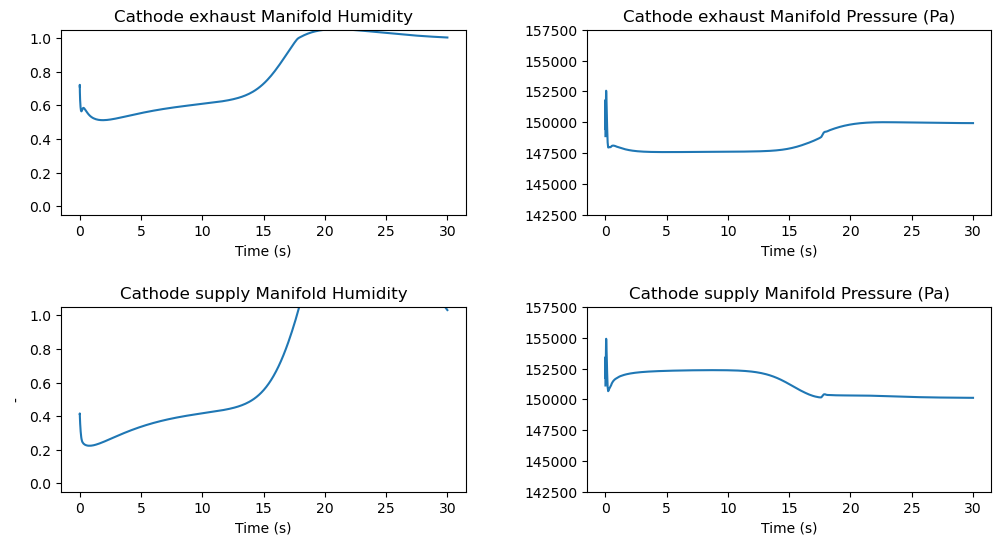

In [ ]:
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(12,6))
plt.subplots_adjust(hspace=0.5, wspace=0.3)
ax[0,0].plot(model.variables['t'], model.variables['Phi_cem'])
ax[0,0].set_xlabel('Time (s)')
ax[0,0].set_title('Cathode exhaust Manifold Humidity')
ax[0,1].plot(model.variables['t'], model.variables['Pcem'])
ax[0,1].set_xlabel('Time (s)')
ax[0,1].set_title('Cathode exhaust Manifold Pressure (Pa)')
ax[1,0].plot(model.variables['t'], model.variables['Phi_csm'])
ax[1,0].set_ylabel('-')
ax[1,0].set_xlabel('Time (s)')
ax[1,0].set_title('Cathode supply Manifold Humidity')
ax[1,1].plot(model.variables['t'], model.variables['Pcsm'])
ax[1,1].set_title('Cathode supply Manifold Pressure (Pa)')
ax[1,1].set_xlabel('Time (s)')
ax[0,0].set_ylim(-0.05, 1.05)
ax[1,0].set_ylim(-0.05, 1.05)
ax[0,1].set_ylim(operating_inputs["Pc_des"] * 0.95, operating_inputs["Pc_des"] * 1.05)
ax[1,1].set_ylim(operating_inputs["Pc_des"] * 0.95, operating_inputs["Pc_des"] * 1.05)

Text(0.5, 1.0, 'Cathode CL water content')

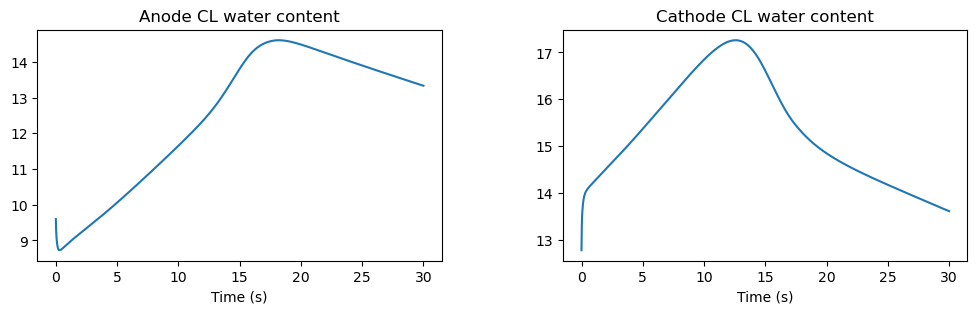

In [ ]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12,3))
plt.subplots_adjust(hspace=0.5, wspace=0.3)
ax[0].plot(model.variables['t'], model.variables['lambda_acl'])
ax[0].set_xlabel('Time (s)')
ax[0].set_title('Anode CL water content')
ax[1].plot(model.variables['t'], model.variables['lambda_ccl'])
ax[1].set_xlabel('Time (s)')
ax[1].set_title('Cathode CL water content')

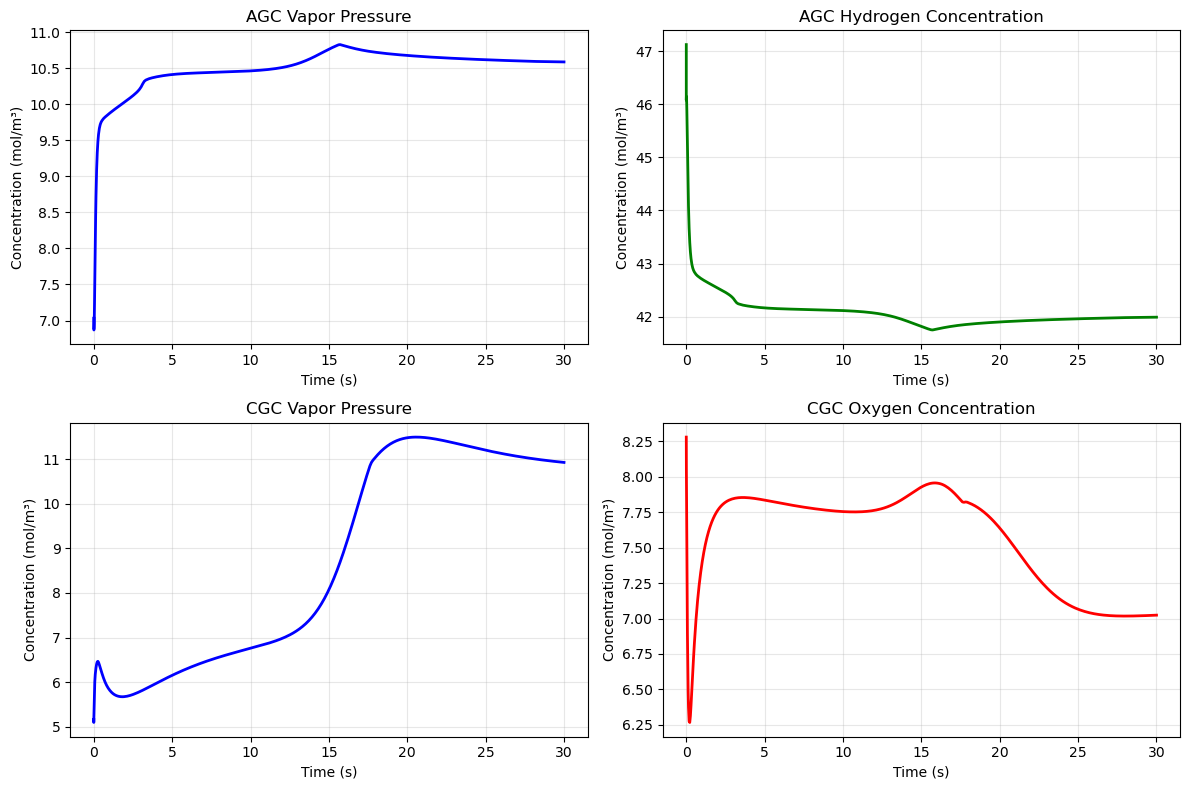

In [ ]:

# Plot gas channel concentrations over time
fig, ax = plt.subplots(2, 2, figsize=(12, 8))
ax = ax.flatten()

# AGC vapor pressure
ax[0].plot(model.variables['t'], model.variables['C_v_agc'], 'b-', linewidth=2)
ax[0].set_title('AGC Vapor Pressure')
ax[0].set_ylabel('Concentration (mol/m³)')
ax[0].set_xlabel('Time (s)')
ax[0].grid(True, alpha=0.3)

# AGC hydrogen
ax[1].plot(model.variables['t'], model.variables['C_H2_agc'], 'g-', linewidth=2)
ax[1].set_title('AGC Hydrogen Concentration')
ax[1].set_ylabel('Concentration (mol/m³)')
ax[1].set_xlabel('Time (s)')
ax[1].grid(True, alpha=0.3)

# CGC vapor pressure
ax[2].plot(model.variables['t'], model.variables['C_v_cgc'], 'b-', linewidth=2)
ax[2].set_title('CGC Vapor Pressure')
ax[2].set_ylabel('Concentration (mol/m³)')
ax[2].set_xlabel('Time (s)')
ax[2].grid(True, alpha=0.3)

# CGC oxygen
ax[3].plot(model.variables['t'], model.variables['C_O2_cgc'], 'r-', linewidth=2)
ax[3].set_title('CGC Oxygen Concentration')
ax[3].set_ylabel('Concentration (mol/m³)')
ax[3].set_xlabel('Time (s)')
ax[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

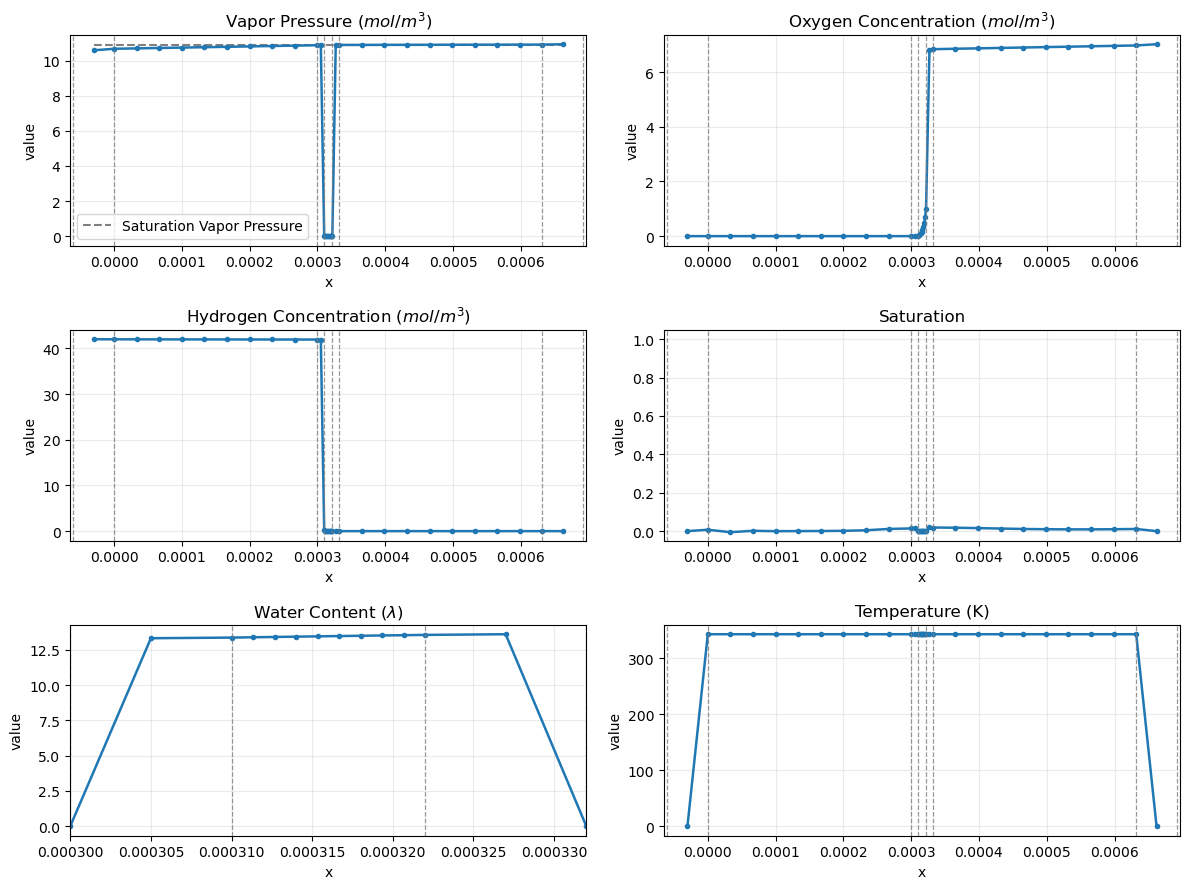

In [ ]:
display(solution=solution, model=model)

## Degradation estimation

(0.2, 1.1)

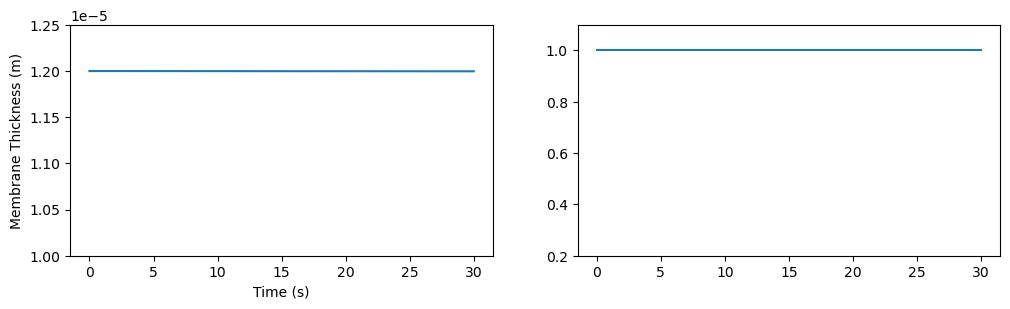

In [ ]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12,3))
ax[0].plot(model.variables['t'], model.variables['delta_mem'], label='Current Density (A)')
ax[0].set_xlabel('Time (s)')
ax[0].set_ylabel('Membrane Thickness (m)')
ax[0].set_ylim(1e-5, 1.25e-5)
ax[1].plot(model.variables['t'], model.echem_traj['S_N'], label='Current Density (A)')
ax[1].set_ylim(0.2, 1.1)